In [1]:
# %pip install torch_geometric
# %pip install ogb
# %pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

In [3]:
import DeviceDir

DIR, RESULTS_DIR = DeviceDir.get_directory()
device, NUM_PROCESSORS = DeviceDir.get_device()

In [15]:
import os
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, Reddit
from torch_geometric.nn import GCNConv
from torch_geometric.loader import ClusterData, ClusterLoader
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import time
from torch_geometric.datasets import WikipediaNetwork
from sklearn.model_selection import train_test_split
from torch_geometric.typing import Adj, SparseTensor
from ogb.nodeproppred import Evaluator, PygNodePropPredDataset
from torch_geometric.utils import scatter
from torch_geometric.datasets import Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset, CitationFull



def fix_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_seeds()

In [2]:
# from torch_geometric.datasets import LINKXDataset
# dataset_name = 'Roman-empire'
# dataset = HeterophilousGraphDataset('/tmp/Cora', DATASET_NAME)
# DATASET_NAME = dataset_name
# data = dataset[0]
# print(data)

In [4]:
from torch_geometric.datasets import Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset,LINKXDataset
def load_dataset(dataset_name):
    if dataset_name == "SmallCora":
        dataset = Planetoid(root=DIR+'/tmp/Cora', name='Cora')
    elif dataset_name in ["Cora", "Cora_ML" "CiteSeer", "DBLP", "PubMed"]:
        dataset = CitationFull(root=DIR+'/tmp/Citation/'+dataset_name, name=dataset_name)
    elif dataset_name == 'Amazon-ratings':
        dataset = HeterophilousGraphDataset(root=DIR+'/tmp/amazon_ratings', name = dataset_name)
    elif dataset_name == 'Roman-empire':
        from torch_geometric.datasets import LINKXDataset
        dataset = LINKXDataset(DIR+'/tmp/Roman_empire', dataset_name)
    elif dataset_name == "Reddit":
        dataset = Reddit(root=DIR+'/tmp/Reddit')
    elif dataset_name == 'penn94':
        from torch_geometric.datasets import LINKXDataset
        dataset = LINKXDataset(root=DIR+'/tmp/LINKX', name=dataset_name)
    elif dataset_name == 'wiki':
        from torch_geometric.datasets import WikiCS
        dataset = WikiCS(root=DIR+'/tmp/WikiCS')
    elif dataset_name == 'Photo':
        dataset = Amazon(root=DIR+'/tmp/Photo', name='Photo')
    elif dataset_name == 'CiteSeer':
        dataset = Planetoid(root=DIR+'/tmp/CiteSeer', name=DATASET_NAME)
    elif dataset_name == 'CS':
        dataset = Coauthor(root=DIR+'/tmp/CS', name = DATASET_NAME)
    elif dataset_name == 'Physics':
        dataset = Coauthor(root=DIR+'/tmp/Physics', name = DATASET_NAME)
    elif dataset_name == 'Minesweeper':
        dataset   = HeterophilousGraphDataset(root=DIR+'/tmp/Mine',name=dataset_name)
    elif dataset_name == 'pokec':
        print("HELLOWROLD ")
    elif dataset_name == 'ogbn-proteins':
        dataset = PygNodePropPredDataset(name='ogbn-proteins', root=DIR+'/tmp/ogbn-proteins')
        data = dataset[0]
        data.node_species = None
        data.y = data.y.to(torch.float)

        # Initialize features of nodes by aggregating edge features.
        row, col = data.edge_index
        data.x = scatter(data.edge_attr, col, dim_size=data.num_nodes, reduce='sum')
        labels = data.y.argmax(dim=1)
        data.y = labels
        return dataset, data
    elif dataset_name == 'squirrel':
        dataset = WikipediaNetwork(root=DIR+'/tmp/squirrel', name='Squirrel')
    elif dataset_name == 'AmazonProducts':
        dataset = AmazonProducts(root=DIR+'/tmp/AmazonProducts')
    else:
        dataset = Planetoid(root=DIR+'/tmp/Cora', name='Cora')

    print(dataset)
    data = dataset[0]
    print(data)
    return dataset, data

# Example usage:
dataset_name = "Cora"
DATASET_NAME = dataset_name
dataset, data = load_dataset(dataset_name)

Processing...


CoraFull()
Data(x=[19793, 8710], edge_index=[2, 126842], y=[19793])


Done!


In [ ]:
# dataset_name = 'Roman-empire'
# DATASET_NAME = dataset_name
# dataset   = HeterophilousGraphDataset(root='/tmp/roman',name=dataset_name)
# data = dataset[0]
# print(data)

In [5]:
dataset.num_classes

70

In [6]:
def train_val_test_mask(data, train=0.4, val=0.3, test=0.3, random_state=False):

    if isinstance(data.x, SparseTensor):
        N = data.x.size(0)
        data.num_nodes = N
    else:
        N = data.x.shape[0]

    indexs = list(range(N))

    if random_state:
        train_index, test_index = train_test_split(indexs, test_size=val+test)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test))
    else:
        train_index, test_index = train_test_split(indexs, test_size=val+test, random_state=1)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test), random_state=1)



    train_mask = torch.zeros(N, dtype=bool)
    train_mask[train_index]=True
    val_mask = torch.zeros(N, dtype=bool)
    val_mask[val_index]=True
    test_mask = torch.zeros(N, dtype=bool)
    test_mask[test_index]=True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask

    return data

In [7]:
if hasattr(data, 'train_mask') == False:
    data = train_val_test_mask(data, train=0.2, val=0.4, test=0.4)

if len(data.train_mask.shape) > 1:
    split_index = 2
    data.train_mask = data.train_mask[:,split_index]
    data.val_mask = data.val_mask[:,split_index]
    data.test_mask = data.test_mask[:,split_index]

data = train_val_test_mask(data, train=0.2, val=0.4, test=0.4)
data

Data(x=[19793, 8710], edge_index=[2, 126842], y=[19793], train_mask=[19793], val_mask=[19793], test_mask=[19793])

In [8]:
# Define the MLP for edge probability
class EdgeProbMLP(nn.Module):
    def __init__(self, in_channels, hidden_dim):
        super(EdgeProbMLP, self).__init__()
        self.fc1 = nn.Linear(2 * in_channels, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, node_features, edge_index):
        edge_features = torch.cat([node_features[edge_index[0]], node_features[edge_index[1]]], dim=1)
        x = F.relu(self.fc1(edge_features))
        prob = torch.sigmoid(self.fc2(x))
        return prob

# Define the overall model with Edge Probabilities and GCNConv (GNN)
class GNNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes):
        super(GNNModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim)
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data, edge_index):
        # Forward pass through two layers of GCNConv with the given edges
        x = F.relu(self.gcn1(data.x, edge_index))
        out = self.gcn2(x, edge_index)
        return out

# Gumbel-Softmax trick for edge sampling
def gumbel_softmax_sampling(edge_probs, edge_index, q=500):
    gumbels = -torch.empty_like(edge_probs).exponential_().log()  # Sample from Gumbel(0, 1)
    logits = (edge_probs + gumbels) / 0.5  # Temperature parameter tau=0.5
    samples = F.softmax(logits, dim=-1)
    sampled_edges = torch.multinomial(samples, q, replacement=False)
    return sampled_edges

# Random edge sampling

def random_edge_sampling(edge_index, q):
    num_edges = edge_index.shape[1]  # Assuming edge_index is of shape [2, num_edges]
    sampled_indices = torch.randperm(num_edges)[:q]
    sampled_edge_index = edge_index[:, sampled_indices]
    return sampled_edge_index


# F1 score calculation helper
def calculate_f1(logits, labels, mask):
    preds = logits[mask].argmax(dim=1)
    f1 = f1_score(labels[mask].cpu(), preds.cpu(), average='micro')
    return f1

# Training function (uses sampled edges)
def train(model, optimizer, criterion, cluster_loader, device, q=500, mode='learned'):
    model.train()
    total_loss = 0

    for batch in cluster_loader:
        if not batch.train_mask.any():
            continue

        batch = batch.to(device)
        optimizer.zero_grad()

        #learned subgraph
        if mode == 'learned':
          # Compute edge probabilities
            if batch.edge_index.shape[1]>q:
                edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()
                # Sample edges using the Gumbel-Softmax trick
                sampled_edge_indices = gumbel_softmax_sampling(edge_probs, batch.edge_index, q=q)
                sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                out = model(batch, sampled_edge_index)
                #print(sampled_edge_index.shape)
            else:
                out = model(batch, batch.edge_index)

        elif mode == 'random':
            # Random subgraph
            if batch.edge_index.shape[1]>q:
                sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                out = model(batch, sampled_edge_index)
                #print(sampled_edge_index.shape)
            else:
                out = model(batch, batch.edge_index)

        elif mode == 'full':
            # Full subgraph
            out = model(batch, batch.edge_index)

        else:
            raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")

        # Compute node classification loss

        #print(batch.num_nodes, batch.edge_index.shape, sample_size, out.shape, batch.y.shape, batch.train_mask.shape)

        loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])

        # Backpropagate loss
        loss.backward()

        # Accumulate gradients and update parameters
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(cluster_loader)

def evaluate(model, cluster_loader, device, q=500, mode=None):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)

            #learned subgraph
            if mode == 'learned':
                if batch.edge_index.shape[1]>q:
                    # Compute edge probabilities
                    edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()
                    # Sample edges using the Gumbel-Softmax trick
                    sampled_edge_indices = gumbel_softmax_sampling(edge_probs, batch.edge_index, q=q)
                    sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                    # Forward pass with sampled edges
                    out = model(batch, sampled_edge_index)
                    #print(sampled_edge_index.shape)
                else:
                    out = model(batch, batch.edge_index)

            elif mode == 'random':
                  # Random subgraph
                if batch.edge_index.shape[1]>q:
                    sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                    out = model(batch, sampled_edge_index)
                    #print(sampled_edge_index.shape)
                else:
                    out = model(batch, batch.edge_index)

            elif mode == 'full':
                # Full subgraph
                out = model(batch, batch.edge_index)

            else:
                raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")


            #print(batch.num_nodes, batch.edge_index.shape, sample_size, out.shape, batch.y.shape, batch.train_mask.shape)

            # Use the full graph's edge_index for evaluation (no sampling)
            out = model(batch, batch.edge_index)

            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1

Main for multiple runs

In [9]:
data

Data(x=[19793, 8710], edge_index=[2, 126842], y=[19793], train_mask=[19793], val_mask=[19793], test_mask=[19793])

In [19]:
RUNS = 1
NUM_EPOCHS = 100
best_test_f1s = []
log = True
mode = 'full' # available modes ['learned', 'random', 'full']

# if hasattr(data, 'train_mask') == False:
#     data = train_val_test_mask(data, train=0.2, val=0.4, test=0.4)

# Clustering using metis

# num_edges_per_partition = 30000
# sample_size = 5000
# num_parts = int(data.edge_index.shape[1]/num_edges_per_partition); #num_parts=150

num_parts = 2
num_edges_per_partition = int(data.edge_index.shape[1]/num_parts)
sample_size = int(num_edges_per_partition*0.10)

print("num_parts:", num_parts, "avg edges per pertition: ", int(data.edge_index.shape[1]/num_parts), "sample size:", sample_size)


start = time.time()
# cluster_data = ClusterData(data, num_parts=num_parts, recursive = False, save_dir = DIR+'tmp/'+DATASET_NAME, filename=None,
#             log = True, keep_inter_cluster_edges = True)


cluster_dir = DIR+'tmp/'+DATASET_NAME
if not os.path.exists(cluster_dir):
    os.makedirs(cluster_dir)
        
cluster_data = ClusterData(data, num_parts=num_parts, recursive = False, save_dir=cluster_dir, log = True)

print("Metis Partition time: ", time.time()-start)

cluster_loader = ClusterLoader(cluster_data, batch_size=1, shuffle=True)

#intialize to store for last iteration
train_f1_scores = np.zeros(NUM_EPOCHS)
val_f1_scores = np.zeros(NUM_EPOCHS)
test_f1_scores = np.zeros(NUM_EPOCHS)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for run in range(RUNS):
    print("Run: ", run)

    # Initialize model
    model = GNNModel(in_channels=dataset.num_node_features, hidden_dim=128, out_channels=64, num_classes=dataset.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    # Train the data
    train_f1_scores = np.zeros(NUM_EPOCHS)
    val_f1_scores = np.zeros(NUM_EPOCHS)
    test_f1_scores = np.zeros(NUM_EPOCHS)

    best_test_f1 = 0

    for epoch in range(NUM_EPOCHS):
        loss = train(model, optimizer, criterion, cluster_loader, device, q=sample_size, mode=mode)
        train_f1, val_f1, test_f1 = evaluate(model, cluster_loader, device, q=sample_size, mode=mode)

        # Store the F1 scores
        train_f1_scores[epoch] = train_f1
        val_f1_scores[epoch] = val_f1
        test_f1_scores[epoch] = test_f1

        # Update the best test F1 score
        if test_f1 > best_test_f1:
            best_test_f1 = test_f1

        if log:
            print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')

    # Print the best test F1 score
    print(f'Best Test F1 Score: {best_test_f1:.4f}')
    best_test_f1s.append(best_test_f1)


# average and standard deviation
print(f'Mean Std of Test F1 Score: {np.mean(best_test_f1s):.4f}+/-{np.std(best_test_f1s):.4f}')

num_parts: 2 avg edges per pertition:  63421 sample size: 6342
Metis Partition time:  0.08913254737854004
Run:  0
Epoch 0, Loss: 4.3544, Train F1: 0.2206, Val F1: 0.1660, Test F1: 0.1641
Epoch 1, Loss: 3.7850, Train F1: 0.3201, Val F1: 0.2454, Test F1: 0.2475
Epoch 2, Loss: 3.2329, Train F1: 0.5023, Val F1: 0.4108, Test F1: 0.4026
Epoch 3, Loss: 2.7518, Train F1: 0.6054, Val F1: 0.5026, Test F1: 0.4972
Epoch 4, Loss: 2.2106, Train F1: 0.6860, Val F1: 0.5700, Test F1: 0.5649
Epoch 5, Loss: 1.7705, Train F1: 0.7405, Val F1: 0.6134, Test F1: 0.6060
Epoch 6, Loss: 1.4275, Train F1: 0.7688, Val F1: 0.6302, Test F1: 0.6219
Epoch 7, Loss: 1.1410, Train F1: 0.7933, Val F1: 0.6441, Test F1: 0.6394
Epoch 8, Loss: 0.9276, Train F1: 0.8156, Val F1: 0.6596, Test F1: 0.6517
Epoch 9, Loss: 0.7642, Train F1: 0.8350, Val F1: 0.6678, Test F1: 0.6603
Epoch 10, Loss: 0.6571, Train F1: 0.8479, Val F1: 0.6664, Test F1: 0.6598
Epoch 11, Loss: 0.5645, Train F1: 0.8638, Val F1: 0.6713, Test F1: 0.6662
Epoch 12

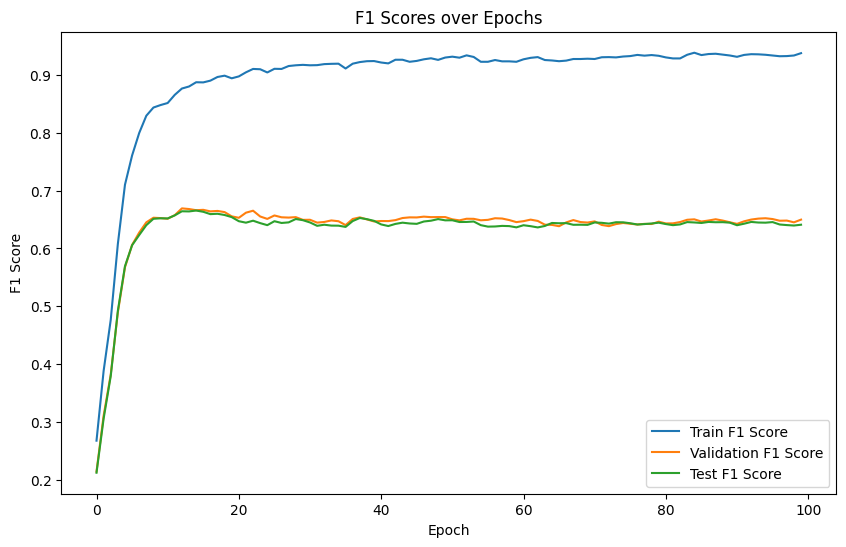

In [17]:
# Plot the F1 scores of last run
plt.figure(figsize=(10, 6))
plt.plot(train_f1_scores, label='Train F1 Score')
plt.plot(val_f1_scores, label='Validation F1 Score')
plt.plot(test_f1_scores, label='Test F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Scores over Epochs')
plt.legend()
plt.show()